# Notebook 07 — Projeto 01: Previsão de Preços de Imóveis

## 🎯 Objetivos

Ao final deste notebook, você será capaz de:

- explorar o dataset California Housing;
- preparar features e target sem vazamento de dados;
- treinar uma rede neural de regressão;
- avaliar MSE, MAE, RMSE e R²;
- analisar previsões e erros do modelo.

> **Como estudar:** execute as células na ordem. Leia a explicação antes de cada bloco e compare os resultados obtidos com a interpretação apresentada.


## 1. Bibliotecas

- NumPy: cálculos numéricos;
- Pandas: manipulação tabular;
- Matplotlib: gráficos;
- TensorFlow: construção da rede;
- `fetch_california_housing`: carregamento do dataset.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_california_housing

## 2. Carregando o California Housing

Com `as_frame=True`, o scikit-learn retorna features e target em estruturas Pandas, preservando os nomes das colunas.


In [6]:
housing = fetch_california_housing(
    as_frame=True
)

### Criando o DataFrame completo

`housing.frame` reúne as oito features e a coluna alvo `MedHouseVal` em uma única tabela.


In [7]:
df = housing.frame

### Primeiras linhas

`head()` ajuda a conferir nomes, tipos aparentes e valores das primeiras observações. Esta é uma inspeção inicial, não uma análise completa.


In [8]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


Nosso modelo terá:


8 características
        ↓
        Rede Neural
        ↓
Valor da casa

Portanto:

X = 8 features
y = 1 target

## 3. Dimensão do dataset

O shape informa quantas observações e colunas existem. A coluna alvo ainda está incluída neste momento.


In [9]:
print("Shape do dataset:")
print(df.shape)

Shape do dataset:
(20640, 9)


### Tipos e valores não nulos

`info()` mostra o tipo de cada coluna, o uso de memória e a quantidade de valores preenchidos.


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Estatísticas descritivas

`describe()` resume contagem, média, desvio padrão, quartis, mínimo e máximo. Observe diferenças de escala entre as features, o que justificará a padronização.


In [11]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### Valores ausentes

A soma de `isnull()` por coluna verifica se será necessário imputar ou remover observações.


In [12]:
print(
    df.isnull().sum()
)

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


### Duplicatas

Linhas duplicadas podem distorcer a distribuição. Aqui verificamos quantas repetições exatas existem.


In [13]:
print(
    "Duplicatas:",
    df.duplicated().sum()
)

Duplicatas: 0


Separando Features e Target

## 4. Separando features e target

`X` contém as oito variáveis explicativas. `y` contém `MedHouseVal`, o valor mediano das casas que queremos prever.


In [14]:
X = df.drop(
    "MedHouseVal",
    axis=1
)

y = df["MedHouseVal"]

### Conferindo shapes

Para regressão supervisionada, esperamos uma matriz `X` bidimensional e um vetor `y` com o mesmo número de observações.


In [15]:
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (20640, 8)
Shape de y: (20640,)


## 5. Distribuição do alvo

O histograma revela a frequência dos valores de `MedHouseVal`. A concentração no limite superior merece atenção: o dataset possui valores do alvo limitados, o que pode afetar a análise dos maiores preços.


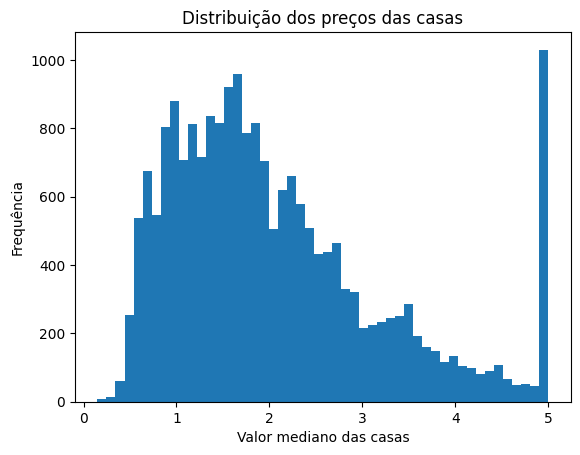

In [16]:
plt.hist(
    y,
    bins=50
)

plt.xlabel(
    "Valor mediano das casas"
)

plt.ylabel(
    "Frequência"
)

plt.title(
    "Distribuição dos preços das casas"
)

plt.show()

Visualizando uma relação importante

Vamos analisar:

Renda mediana

        ↓
Preço das casas

### Relação entre renda e preço

O gráfico de dispersão permite observar tendência, variabilidade e possíveis limites. Correlação visual não implica causalidade.


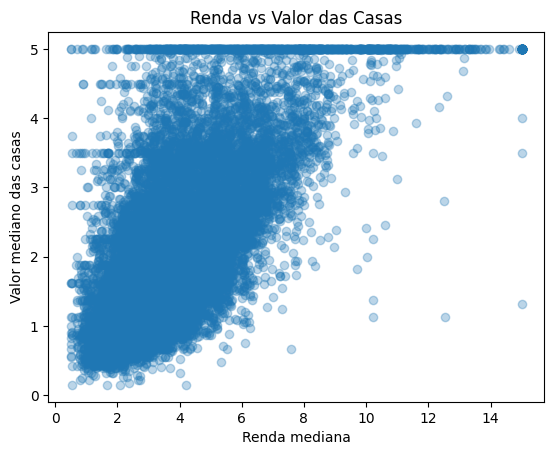

In [17]:
plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3
)

plt.xlabel(
    "Renda mediana"
)

plt.ylabel(
    "Valor mediano das casas"
)

plt.title(
    "Renda vs Valor das Casas"
)

plt.show()

## 6. Matriz de correlação

A correlação linear varia de -1 a 1. Valores próximos dos extremos indicam associação linear mais forte; valores próximos de zero não descartam relações não lineares.


In [18]:
correlacao = df.corr()

print(correlacao)

               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119034  0.326895  -0.062040    0.004834  0.018766   
HouseAge    -0.119034  1.000000 -0.153277  -0.077747   -0.296244  0.013191   
AveRooms     0.326895 -0.153277  1.000000   0.847621   -0.072213 -0.004852   
AveBedrms   -0.062040 -0.077747  0.847621   1.000000   -0.066197 -0.006181   
Population   0.004834 -0.296244 -0.072213  -0.066197    1.000000  0.069863   
AveOccup     0.018766  0.013191 -0.004852  -0.006181    0.069863  1.000000   
Latitude    -0.079809  0.011173  0.106389   0.069721   -0.108785  0.002366   
Longitude   -0.015176 -0.108197 -0.027540   0.013344    0.099773  0.002476   
MedHouseVal  0.688075  0.105623  0.151948  -0.046701   -0.024650 -0.023737   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079809  -0.015176     0.688075  
HouseAge     0.011173  -0.108197     0.105623  
AveRooms     0.106389  -0.027540     0.151948  
AveBedrms    0.069721   0.0

### Mapa visual das correlações

`imshow` representa a matriz por intensidades. Os rótulos permitem localizar quais pares de variáveis estão sendo comparados.


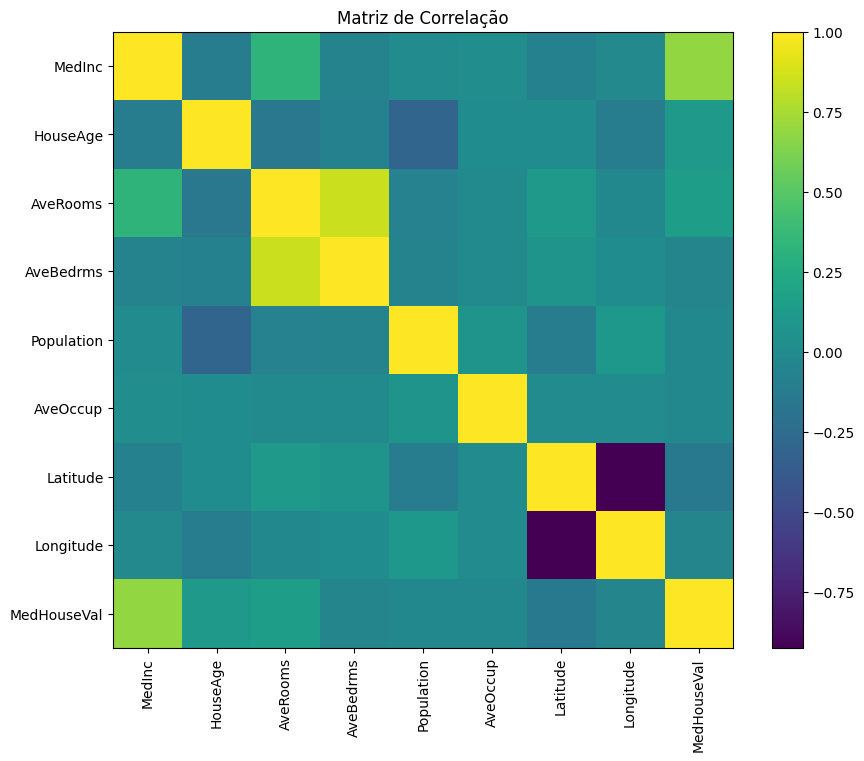

In [19]:
plt.figure(
    figsize=(10, 8)
)

plt.imshow(
    correlacao,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlacao.columns)),
    correlacao.columns,
    rotation=90
)

plt.yticks(
    range(len(correlacao.columns)),
    correlacao.columns
)

plt.title(
    "Matriz de Correlação"
)

plt.show()

Até agora, nosso modelo artificial era:

X
↓
y = 2x₁ + 3x₂

Nós sabíamos exatamente como os dados eram gerados.

Agora:

X
↓
?????
↓
Preço da casa

Nós não sabemos a fórmula.

Essa é uma das grandes diferenças entre o exercício anterior e Machine Learning real.

O modelo precisa descobrir padrões nos dados.

## 7. Escala do target

Antes de interpretar MAE ou RMSE, precisamos conhecer a unidade e a faixa de `y`. No dataset, `MedHouseVal` é expresso em centenas de milhares de dólares.


In [20]:
print(
    y.describe()
)

count    20640.000000
mean         2.068558
std          1.153956
min          0.149990
25%          1.196000
50%          1.797000
75%          2.647250
max          5.000010
Name: MedHouseVal, dtype: float64


### Resumo direto do alvo

Mínimo, máximo, média e mediana complementam a análise da distribuição.


In [21]:
print("Valor mínimo:", y.min())
print("Valor máximo:", y.max())
print("Valor médio:", y.mean())
print("Mediana:", y.median())

Valor mínimo: 0.14999
Valor máximo: 5.00001
Valor médio: 2.068558169089147
Mediana: 1.797


## 8. Divisão dos dados

`train_test_split` será usado em duas etapas para formar aproximadamente 70% de treino, 15% de validação e 15% de teste.


In [23]:
from sklearn.model_selection import train_test_split

### Separando o teste

O teste fica isolado desde o início e só será usado na avaliação final. `random_state=42` torna a divisão reproduzível.


In [24]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    random_state=42
)

### Separando treino e validação

A validação será usada para acompanhar a generalização durante o treinamento e para o Early Stopping.


In [25]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.1765,
    random_state=42
)

### Conferindo as divisões

Os shapes confirmam que não perdemos observações e que X e y permanecem alinhados em cada subconjunto.


In [26]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nX_val:", X_val.shape)
print("y_val:", y_val.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (14447, 8)
y_train: (14447,)

X_val: (3097, 8)
y_val: (3097,)

X_test: (3096, 8)
y_test: (3096,)


## 9. Padronização

`StandardScaler` transforma cada feature para média próxima de zero e desvio padrão próximo de um, com base apenas no treino.


In [27]:
from sklearn.preprocessing import StandardScaler

### Criando o scaler

Neste momento o objeto ainda não conhece nenhuma estatística dos dados.


In [28]:
scaler = StandardScaler()

### Ajustando somente no treino

Esta regra evita **data leakage**. Usar validação ou teste no `fit` faria o pré-processamento incorporar informações externas ao treinamento.


In [29]:
scaler.fit(X_train)

StandardScaler()

### Transformando treino

A saída deixa de ser DataFrame e passa a ser um array NumPy padronizado.


In [30]:
X_train_scaled = scaler.transform(
    X_train
)

### Transformando validação

Aplicamos exatamente a média e o desvio aprendidos no treino.


In [31]:
X_val_scaled = scaler.transform(
    X_val
)

### Transformando teste

O teste recebe a mesma transformação, sem recalcular parâmetros.


In [32]:
X_test_scaled = scaler.transform(
    X_test
)

### Comparando dados originais

Estas linhas preservam os valores e nomes de colunas antes da transformação.


In [33]:
print(
    "Primeiros 5 exemplos originais:"
)

print(
    X_train.head()
)

Primeiros 5 exemplos originais:
       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
7052   3.2371      33.0  4.289700   1.008584      2170.0  4.656652     33.92   
4464   1.9038      35.0  4.155080   1.018717      1487.0  3.975936     34.08   
13229  8.5282      25.0  7.831050   1.107306      1284.0  2.931507     34.15   
6964   3.7833      47.0  5.438356   1.058219       827.0  2.832192     33.99   
17596  4.5795      28.0  6.025391   1.078125      1277.0  2.494141     37.31   

       Longitude  
7052     -118.05  
4464     -118.19  
13229    -117.66  
6964     -118.06  
17596    -121.88  


### Dados padronizados

Agora as colunas estão em escalas comparáveis. Os valores não ficam necessariamente entre 0 e 1.


In [34]:
print(
    "\nPrimeiros 5 exemplos normalizados:"
)

print(
    X_train_scaled[:5]
)


Primeiros 5 exemplos normalizados:
[[-3.32955953e-01  3.50623009e-01 -4.40301467e-01 -1.73875607e-01
   6.51571539e-01  1.34599860e-01 -8.07328980e-01  7.63595443e-01]
 [-1.03691418e+00  5.09347392e-01 -4.92098184e-01 -1.54061679e-01
   5.31288903e-02  7.61900944e-02 -7.32526809e-01  6.93771695e-01]
 [ 2.46064894e+00 -2.84274525e-01  9.22283699e-01  1.91666661e-02
  -1.24739130e-01 -1.34284897e-02 -6.99800859e-01  9.58104454e-01]
 [-4.45722539e-02  1.46169369e+00  1.66053769e-03 -7.68179759e-02
  -5.25161224e-01 -2.19503481e-02 -7.74603030e-01  7.58608032e-01]
 [ 3.75806914e-01 -4.61879496e-02  2.27530418e-01 -3.78939714e-02
  -1.30872510e-01 -5.09572662e-02  7.77542020e-01 -1.14658280e+00]]


### Verificando a média

Pequenos valores residuais próximos de zero aparecem por precisão numérica.


In [35]:
print(
    "Média das features:"
)

print(
    X_train_scaled.mean(axis=0)
)

Média das features:
[ 2.25256851e-16  1.57384700e-17 -1.34514735e-16  3.30753783e-17
 -8.26269673e-17  2.45913593e-17  1.94308626e-15 -2.05165711e-15]


### Verificando o desvio padrão

O resultado próximo de 1 confirma a padronização do conjunto de treino.


In [36]:
print(
    "\nDesvio padrão:"
)

print(
    X_train_scaled.std(axis=0)
)


Desvio padrão:
[1. 1. 1. 1. 1. 1. 1. 1.]


## 10. Construindo o Modelo V1

Arquitetura:

`8 entradas → Dense(64, ReLU) → Dense(32, ReLU) → Dense(16, ReLU) → 1 saída`

A camada final não usa ativação, pois o problema é de regressão e precisamos prever um valor contínuo.


In [37]:
model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        64,
        activation="relu",
        input_shape=(8,)
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        1
    )
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 11. Compilação

- Adam com learning rate `0.001` atualiza os parâmetros;
- MSE é a função otimizada;
- MAE é acompanhada como métrica interpretável.


In [38]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

### Resumo da arquitetura

`summary()` mostra shapes e quantidade de parâmetros. Para uma Dense, os parâmetros são `(entradas × neurônios) + biases`.


In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

A arquitetura ficou:

8 FEATURES

    │
    ▼

┌───────────────┐

│ Dense(64)     │

│ ReLU          │

│ 576 parâmetros│

└───────┬───────┘

        │
        ▼
┌───────────────┐

│ Dense(32)     │

│ ReLU          │

│ 2080 parâmetros│

└───────┬───────┘

        │
        ▼
┌───────────────┐

│ Dense(16)     │

│ ReLU          │

│ 528 parâmetros│



        │
        ▼
┌───────────────┐

│ Dense(1)      │

│ Preço         │

│ 17 parâmetros │

└───────────────┘

Total:

3.201 parâmetros treináveis

Isso significa que a rede possui 3.201 valores que podem ser ajustados durante o treinamento.

Por que a primeira camada tem 576 parâmetros?

Você tem:

8 entradas
64 neurônios

Cada neurônio recebe 8 entradas:

8 pesos
+
1 bias
=
9 parâmetros

Para 64 neurônios:

9 × 64 = 576

Exatamente o que aparece no summary().

## 12. Early Stopping

O callback observa `val_loss`. Se não houver melhora por 20 épocas, interrompe o treinamento e restaura os melhores pesos encontrados.


In [40]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

Estamos dizendo:

Observe:

val_loss

Se não melhorar durante:

20 épocas

Pare o treinamento.

Depois:

Volte para os melhores pesos encontrados.

Isso evita que o modelo continue treinando desnecessariamente.

## 13. Treinamento

- `epochs=500` define o máximo;
- `batch_size=32` controla quantos exemplos entram em cada atualização;
- `validation_data` calcula métricas sem atualizar pesos;
- o Early Stopping pode encerrar antes das 500 épocas.


In [41]:
history = model.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=500,

    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/500
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.9999 - mae: 0.6492 - val_loss: 0.4599 - val_mae: 0.4736
Epoch 2/500
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.4229 - mae: 0.4582 - val_loss: 0.3815 - val_mae: 0.4393
Epoch 3/500
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3890 - mae: 0.4367 - val_loss: 0.3573 - val_mae: 0.4261
Epoch 4/500
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3517 - mae: 0.4185 - val_loss: 0.3442 - val_mae: 0.4074
Epoch 5/500
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3390 - mae: 0.4072 - val_loss: 0.3304 - val_mae: 0.3996
Epoch 6/500
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3324 - mae: 0.3984 - val_loss: 0.3590 - val_mae: 0.4044
Epoch 7/500
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.3145 - mae: 0.3913 - val_loss: 0.3138 - val_mae: 0.3954
Epoch 8/500
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3062 - mae: 0.3854 - val_loss: 0.3160 - val_mae: 0.3807
Epoch 9/500
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

Aqui temos:

X_train_scaled

        ↓

Rede Neural

        ↓

Predição

        ↓

Comparação com y_train

        ↓
Loss

        ↓
Backpropagation

        ↓
Atualização dos pesos

E ao mesmo tempo:

X_val_scaled

        ↓
      
Rede Neural

        ↓
Predição

        ↓
Validação

O conjunto de validação não atualiza os pesos.

### Quantas épocas foram executadas?

O comprimento do histórico mostra em que momento o Early Stopping interrompeu o processo.


In [42]:
print(
    "Épocas executadas:",
    len(history.history["loss"])
)

Épocas executadas: 93


## 14. Curvas de loss

Comparamos MSE de treino e validação. Uma separação crescente pode indicar overfitting; valores altos em ambos podem indicar underfitting.


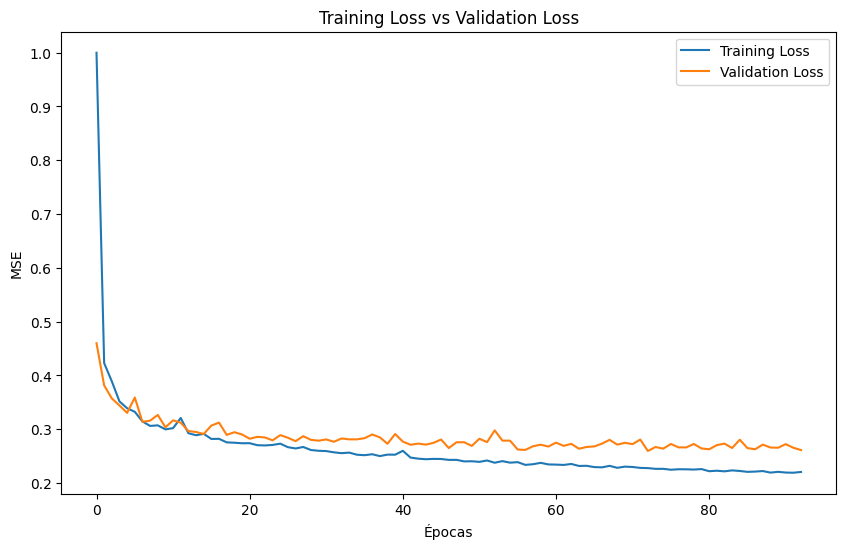

In [43]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Épocas"
)

plt.ylabel(
    "MSE"
)

plt.title(
    "Training Loss vs Validation Loss"
)

plt.legend()

plt.show()

### Curvas de MAE

A MAE oferece outra visão do aprendizado e está na mesma unidade do target.


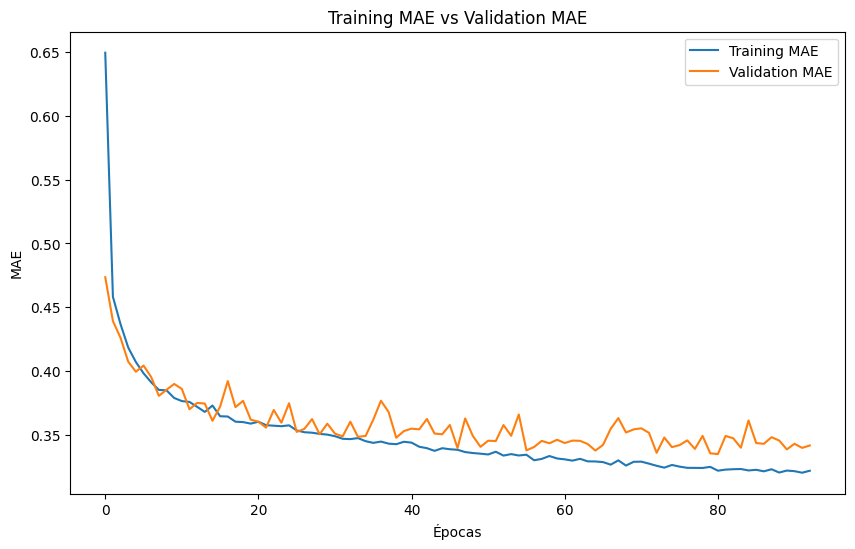

In [44]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history.history["mae"],
    label="Training MAE"
)

plt.plot(
    history.history["val_mae"],
    label="Validation MAE"
)

plt.xlabel(
    "Épocas"
)

plt.ylabel(
    "MAE"
)

plt.title(
    "Training MAE vs Validation MAE"
)

plt.legend()

plt.show()

## 15. Avaliação final no teste

Somente agora utilizamos o conjunto de teste. Ele estima o desempenho em dados não usados para treinar nem para decidir quando parar.


In [45]:
test_loss, test_mae = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2660 - mae: 0.3467


### MSE e MAE de teste

A loss retornada é o MSE. A segunda saída corresponde à MAE definida em `compile`.


In [46]:
print(
    "Test Loss:",
    test_loss
)

print(
    "Test MAE:",
    test_mae
)

Test Loss: 0.26604411005973816
Test MAE: 0.346748024225235


## 16. Selecionando uma amostra

Escolhemos os dez primeiros exemplos do teste para comparar previsões individuais.


In [47]:
X_amostra = X_test_scaled[:10]
y_real = y_test.iloc[:10].values

### Gerando previsões

`predict` retorna uma matriz com uma coluna. Depois usaremos `flatten()` para convertê-la em vetor.


In [48]:
previsoes = model.predict(
    X_amostra,
    verbose=0
)

### Valores reais versus previstos

Diferenças são esperadas. O objetivo é avaliar o padrão geral e não exigir acerto perfeito em cada observação.


In [49]:
print(
    "Valor real:"
)

print(
    y_real
)

print(
    "\nPrevisão:"
)

print(
    previsoes.flatten()
)

Valor real:
[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]

Previsão:
[0.5910572  0.91824806 5.32911    2.5513003  2.6123092  1.4826577
 2.2814825  1.5558078  2.775056   4.8049927 ]


### Comparação visual da amostra

O gráfico permite identificar rapidamente em quais exemplos a previsão ficou acima ou abaixo do valor real.


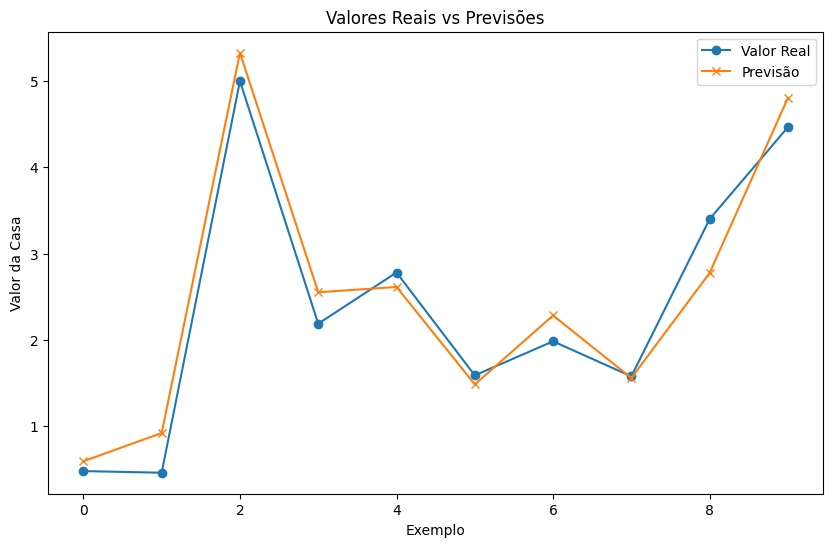

In [50]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    y_real,
    marker="o",
    label="Valor Real"
)

plt.plot(
    previsoes.flatten(),
    marker="x",
    label="Previsão"
)

plt.xlabel(
    "Exemplo"
)

plt.ylabel(
    "Valor da Casa"
)

plt.title(
    "Valores Reais vs Previsões"
)

plt.legend()

plt.show()

## 17. Resíduos

Definimos o erro como `real - previsão`. Erro positivo indica subestimação; erro negativo indica superestimação.


In [51]:
erros = (
    y_test.values
    - model.predict(
        X_test_scaled,
        verbose=0
    ).flatten()
)

### Erro absoluto

O valor absoluto ignora o sentido e mede apenas o tamanho do erro.


In [52]:
erros_absolutos = np.abs(
    erros
)

### Tabela de resultados

Reunimos valor real, previsão, erro assinado e erro absoluto para facilitar a investigação.


In [53]:
df_resultados = pd.DataFrame({
    "Real": y_test.values,
    "Previsao": model.predict(
        X_test_scaled,
        verbose=0
    ).flatten(),
    "Erro": erros,
    "Erro_Absoluto": erros_absolutos
})

### Primeiras observações da tabela

Esta visualização permite conferir se os cálculos foram montados corretamente.


In [54]:
print(
    df_resultados.head(10)
)

      Real  Previsao      Erro  Erro_Absoluto
0  0.47700  0.591057 -0.114057       0.114057
1  0.45800  0.918248 -0.460248       0.460248
2  5.00001  5.329110 -0.329100       0.329100
3  2.18600  2.551300 -0.365300       0.365300
4  2.78000  2.612309  0.167691       0.167691
5  1.58700  1.482658  0.104342       0.104342
6  1.98200  2.281482 -0.299482       0.299482
7  1.57500  1.555808  0.019192       0.019192
8  3.40000  2.775056  0.624944       0.624944
9  4.46600  4.804993 -0.338993       0.338993


### Maiores erros

Ordenar por erro absoluto revela casos extremos. Esses casos podem indicar regiões do espaço de dados mais difíceis para o modelo.


In [55]:
maiores_erros = df_resultados.sort_values(
    "Erro_Absoluto",
    ascending=False
)

print(
    maiores_erros.head(10)
)

         Real  Previsao      Erro  Erro_Absoluto
1649  5.00001  0.880895  4.119115       4.119115
872   5.00001  1.690665  3.309345       3.309345
2558  1.87500  4.914237 -3.039237       3.039237
285   1.25000  4.278844 -3.028844       3.028844
1140  5.00001  2.063890  2.936120       2.936120
1865  5.00001  2.149573  2.850437       2.850437
3054  5.00001  2.368980  2.631030       2.631030
1569  4.78600  2.177394  2.608606       2.608606
1138  5.00001  2.532632  2.467378       2.467378
429   5.00001  2.555910  2.444100       2.444100


## 18. Real versus previsto

Em um modelo ideal, os pontos ficariam próximos da diagonal `y = x`. Dispersão em torno dessa linha representa erro.


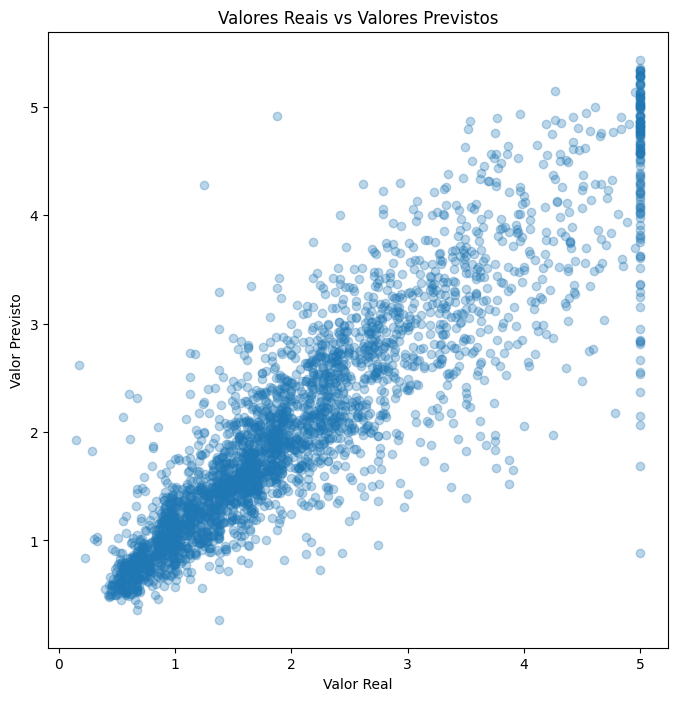

In [56]:
plt.figure(
    figsize=(8, 8)
)

plt.scatter(
    y_test,
    df_resultados["Previsao"],
    alpha=0.3
)

plt.xlabel(
    "Valor Real"
)

plt.ylabel(
    "Valor Previsto"
)

plt.title(
    "Valores Reais vs Valores Previstos"
)

plt.show()

### Erro percentual

O erro percentual facilita comparações relativas, mas pode ficar muito alto quando o valor real é pequeno. Deve ser interpretado com cautela.


In [57]:
df_resultados["Erro_Percentual"] = (
    df_resultados["Erro_Absoluto"]
    / np.abs(df_resultados["Real"])
) * 100

### Inspecionando percentuais

A tabela combina erro absoluto e relativo para uma leitura mais completa.


In [58]:
print(
    df_resultados[
        [
            "Real",
            "Previsao",
            "Erro_Absoluto",
            "Erro_Percentual"
        ]
    ].head(10)
)

      Real  Previsao  Erro_Absoluto  Erro_Percentual
0  0.47700  0.591057       0.114057        23.911359
1  0.45800  0.918248       0.460248       100.490842
2  5.00001  5.329110       0.329100         6.581990
3  2.18600  2.551300       0.365300        16.710901
4  2.78000  2.612309       0.167691         6.032043
5  1.58700  1.482658       0.104342         6.574816
6  1.98200  2.281482       0.299482        15.110114
7  1.57500  1.555808       0.019192         1.218551
8  3.40000  2.775056       0.624944        18.380709
9  4.46600  4.804993       0.338993         7.590521


## 19. RMSE

A raiz do MSE volta à unidade do target e penaliza erros grandes mais intensamente do que a MAE.


In [59]:
rmse = np.sqrt(test_loss)

print(
    "RMSE:",
    rmse
)

RMSE: 0.5157946394251671


## 20. Coeficiente de determinação

Importamos `r2_score` para medir a proporção da variabilidade do alvo explicada pelo modelo em relação a uma previsão baseada apenas na média.


In [60]:
from sklearn.metrics import r2_score

### Previsões de todo o teste

Geramos uma única vez o vetor completo usado no cálculo de R².


In [61]:
y_pred = model.predict(
    X_test_scaled,
    verbose=0
).flatten()

### Calculando R²

Valores próximos de 1 indicam melhor ajuste. R² igual a 0 equivale, nesse critério, a prever a média; valores negativos indicam desempenho pior que essa referência.


In [62]:
r2 = r2_score(
    y_test,
    y_pred
)

print(
    "R²:",
    r2
)

R²: 0.7969916162523164


## 21. Relatório consolidado

Reunimos as quatro métricas principais para registrar o desempenho do Modelo V1.


In [63]:
print("===== AVALIAÇÃO DO MODELO V1 =====")

print(
    f"Test Loss (MSE): {test_loss:.4f}"
)

print(
    f"MAE: {test_mae:.4f}"
)

print(
    f"RMSE: {rmse:.4f}"
)

print(
    f"R²: {r2:.4f}"
)

===== AVALIAÇÃO DO MODELO V1 =====
Test Loss (MSE): 0.2660
MAE: 0.3467
RMSE: 0.5158
R²: 0.7970


### Melhor validation loss

O menor valor do histórico indica o melhor ponto observado durante o treinamento.


In [64]:
print(
    "Melhor Validation Loss:"
)

print(
    min(
        history.history["val_loss"]
    )
)

Melhor Validation Loss:
0.2596128284931183


### Melhor época

`argmin` retorna o índice do menor `val_loss`; somamos 1 porque índices Python começam em zero, mas épocas são contadas a partir de um.


In [65]:
melhor_epoca = (
    np.argmin(
        history.history["val_loss"]
    ) + 1
)

print(
    "Melhor época:",
    melhor_epoca
)

Melhor época: 73


### Estado final do histórico

Comparamos as últimas losses de treino e validação. Como `restore_best_weights=True`, os pesos atuais do modelo correspondem à melhor validação, não necessariamente à última época registrada.


In [66]:
print(
    "Último Training Loss:",
    history.history["loss"][-1]
)

print(
    "Último Validation Loss:",
    history.history["val_loss"][-1]
)

print(
    "Melhor Validation Loss:",
    min(
        history.history["val_loss"]
    )
)

Último Training Loss: 0.22058501839637756
Último Validation Loss: 0.2612738609313965
Melhor Validation Loss: 0.2596128284931183


# 🧪 Experimentos pós-projeto

Depois de construir e avaliar o primeiro modelo, iniciaremos uma sequência de experimentos controlados.

O objetivo é verificar se alterações na arquitetura realmente melhoram a capacidade de generalização do modelo.

Para tornar a comparação mais justa, os novos modelos utilizarão:

- a mesma divisão entre treino, validação e teste;
- o mesmo `StandardScaler`;
- a mesma seed;
- o mesmo otimizador;
- o mesmo `learning_rate`;
- o mesmo número máximo de épocas;
- o mesmo `batch_size`;
- o mesmo critério de `EarlyStopping`.

Nesta etapa, vamos:

1. definir seeds para melhorar a reprodutibilidade;
2. recriar o Modelo V1 em condições controladas;
3. treinar uma rede menor;
4. comparar os dois modelos em uma tabela única.


## 1. Reprodutibilidade dos experimentos

Redes neurais possuem elementos aleatórios, como:

- inicialização dos pesos;
- embaralhamento dos exemplos;
- operações internas do TensorFlow;
- comportamento do Dropout, quando utilizado.

Ao definir uma seed, reduzimos a variação entre execuções e tornamos os resultados mais comparáveis.

Mesmo com seeds fixas, pequenas diferenças ainda podem ocorrer dependendo do hardware e de determinadas operações internas.


In [ ]:
import os
import random

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("Operações determinísticas ativadas.")
except Exception:
    print("Não foi possível ativar o determinismo completo neste ambiente.")

print(f"Seed definida: {SEED}")


### Função auxiliar para preparar cada experimento

Antes de criar cada modelo, vamos:

1. limpar a sessão anterior do Keras;
2. redefinir as seeds;
3. iniciar o novo modelo nas mesmas condições aleatórias.

Isso reduz a influência de modelos treinados anteriormente e facilita uma comparação mais justa.


In [ ]:
def preparar_experimento(seed=42):
    tf.keras.backend.clear_session()

    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)


## 2. Modelo V1 controlado

O Modelo V1 original apresentou um bom resultado, mas foi treinado antes da definição explícita das seeds.

Vamos recriar a mesma arquitetura:

```text
8 entradas
    ↓
64 neurônios
    ↓
32 neurônios
    ↓
16 neurônios
    ↓
1 saída
```

As camadas ocultas utilizam ReLU e a camada de saída não possui função de ativação, pois estamos resolvendo um problema de regressão.


In [ ]:
preparar_experimento(SEED)

model_v1_controlado = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_train_scaled.shape[1],)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(1)
])

model_v1_controlado.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

model_v1_controlado.summary()


### Early Stopping do Modelo V1 controlado

Criamos um callback exclusivo para este treinamento.

O treinamento será interrompido quando o `val_loss` deixar de melhorar por 20 épocas consecutivas. Ao final, os melhores pesos encontrados serão restaurados.


In [ ]:
early_stopping_v1_controlado = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)


In [ ]:
history_v1_controlado = model_v1_controlado.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=500,
    batch_size=32,

    callbacks=[
        early_stopping_v1_controlado
    ],

    verbose=1
)


### Avaliação do Modelo V1 controlado

As métricas serão calculadas diretamente a partir das previsões.

Essa estratégia será importante nos próximos experimentos com regularização, pois a `loss` retornada pelo Keras pode incluir penalizações como L2. Ao usar as previsões, todos os modelos são avaliados pelo mesmo critério.


In [ ]:
y_pred_v1_controlado = model_v1_controlado.predict(
    X_test_scaled,
    verbose=0
).flatten()

mse_v1_controlado = mean_squared_error(
    y_test,
    y_pred_v1_controlado
)

mae_v1_controlado = mean_absolute_error(
    y_test,
    y_pred_v1_controlado
)

rmse_v1_controlado = np.sqrt(
    mse_v1_controlado
)

r2_v1_controlado = r2_score(
    y_test,
    y_pred_v1_controlado
)

epocas_v1_controlado = len(
    history_v1_controlado.history["loss"]
)

print("===== MODELO V1 CONTROLADO =====")
print(f"MSE: {mse_v1_controlado:.4f}")
print(f"MAE: {mae_v1_controlado:.4f}")
print(f"RMSE: {rmse_v1_controlado:.4f}")
print(f"R²: {r2_v1_controlado:.4f}")
print(f"Épocas executadas: {epocas_v1_controlado}")
print(f"Parâmetros: {model_v1_controlado.count_params()}")


## 3. Modelo menor

Agora vamos testar uma rede com menos camadas e menos neurônios:

```text
8 entradas
    ↓
32 neurônios
    ↓
16 neurônios
    ↓
1 saída
```

### Hipótese

Uma rede menor pode:

- treinar mais rapidamente;
- reduzir o risco de overfitting;
- alcançar desempenho semelhante ao Modelo V1;
- utilizar menos parâmetros;
- ser suficiente para a complexidade deste dataset.

Um modelo maior não é automaticamente melhor. Caso a rede menor apresente desempenho semelhante, ela pode ser preferível por ser mais simples.


In [ ]:
preparar_experimento(SEED)

model_menor = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_train_scaled.shape[1],)
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(1)
])

model_menor.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

model_menor.summary()


In [ ]:
early_stopping_menor = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)


In [ ]:
history_menor = model_menor.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=500,
    batch_size=32,

    callbacks=[
        early_stopping_menor
    ],

    verbose=1
)


### Avaliação do modelo menor

Vamos utilizar exatamente as mesmas métricas do Modelo V1 controlado:

- MSE;
- MAE;
- RMSE;
- R²;
- quantidade de épocas;
- quantidade de parâmetros.


In [ ]:
y_pred_menor = model_menor.predict(
    X_test_scaled,
    verbose=0
).flatten()

mse_menor = mean_squared_error(
    y_test,
    y_pred_menor
)

mae_menor = mean_absolute_error(
    y_test,
    y_pred_menor
)

rmse_menor = np.sqrt(
    mse_menor
)

r2_menor = r2_score(
    y_test,
    y_pred_menor
)

epocas_menor = len(
    history_menor.history["loss"]
)

print("===== MODELO MENOR =====")
print(f"MSE: {mse_menor:.4f}")
print(f"MAE: {mae_menor:.4f}")
print(f"RMSE: {rmse_menor:.4f}")
print(f"R²: {r2_menor:.4f}")
print(f"Épocas executadas: {epocas_menor}")
print(f"Parâmetros: {model_menor.count_params()}")


## 4. Comparação entre os modelos

Agora reuniremos os resultados em uma única tabela.

Para regressão:

- valores menores de MSE, MAE e RMSE são melhores;
- valores maiores de R² são melhores;
- menos parâmetros podem ser vantajosos quando o desempenho é semelhante;
- menos épocas podem indicar convergência mais rápida.

A escolha do melhor modelo não deve considerar apenas uma métrica isolada.


In [ ]:
comparacao_modelos = pd.DataFrame({
    "Modelo": [
        "V1 controlado",
        "Modelo menor"
    ],

    "Arquitetura": [
        "64 → 32 → 16",
        "32 → 16"
    ],

    "MSE": [
        mse_v1_controlado,
        mse_menor
    ],

    "MAE": [
        mae_v1_controlado,
        mae_menor
    ],

    "RMSE": [
        rmse_v1_controlado,
        rmse_menor
    ],

    "R²": [
        r2_v1_controlado,
        r2_menor
    ],

    "Épocas": [
        epocas_v1_controlado,
        epocas_menor
    ],

    "Parâmetros": [
        model_v1_controlado.count_params(),
        model_menor.count_params()
    ]
})

comparacao_modelos.sort_values(
    by="RMSE"
).reset_index(drop=True)


### Comparando as curvas de validação

Além das métricas finais, devemos observar o comportamento do erro de validação durante o treinamento.

Uma curva de validação instável ou que começa a crescer enquanto o erro de treino continua diminuindo pode indicar overfitting.


In [ ]:
plt.figure(
    figsize=(10, 6)
)

plt.plot(
    history_v1_controlado.history["val_loss"],
    label="V1 controlado - Validation Loss"
)

plt.plot(
    history_menor.history["val_loss"],
    label="Modelo menor - Validation Loss"
)

plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.title("Comparação do Validation Loss")
plt.legend()
plt.show()


## Como interpretar a comparação?

O modelo menor pode ser considerado uma opção melhor quando:

- apresenta MSE, MAE e RMSE próximos ou menores;
- mantém R² semelhante ou maior;
- utiliza significativamente menos parâmetros;
- apresenta curvas de treino e validação estáveis.

Uma pequena diferença no R² pode não justificar uma arquitetura maior.

Por exemplo, caso os resultados fossem:

```text
V1 controlado: R² = 0,797
Modelo menor:  R² = 0,795
```

a diferença seria pequena e a rede menor poderia ser preferida por sua simplicidade.

A decisão final deve ser tomada somente depois de executar as células e analisar os resultados reais.


# 🔐 Experimento 3 — Regularização L2

A regularização L2 adiciona uma penalização proporcional ao quadrado dos pesos da rede.

Seu objetivo é evitar que o modelo dependa excessivamente de pesos muito altos, o que pode reduzir o risco de overfitting.

Neste experimento, manteremos a arquitetura do Modelo V1:

```text
8 entradas
    ↓
64 neurônios + L2
    ↓
32 neurônios + L2
    ↓
16 neurônios
    ↓
1 saída
```

A intensidade da regularização será:

```python
l2(0.001)
```

Todos os demais elementos permanecerão iguais para que a comparação seja justa.


In [ ]:
preparar_experimento(SEED)

model_l2 = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_train_scaled.shape[1],)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(1)
])

model_l2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

model_l2.summary()


In [ ]:
early_stopping_l2 = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_l2 = model_l2.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=500,
    batch_size=32,

    callbacks=[
        early_stopping_l2
    ],

    verbose=1
)


In [ ]:
y_pred_l2 = model_l2.predict(
    X_test_scaled,
    verbose=0
).flatten()

mse_l2 = mean_squared_error(
    y_test,
    y_pred_l2
)

mae_l2 = mean_absolute_error(
    y_test,
    y_pred_l2
)

rmse_l2 = np.sqrt(
    mse_l2
)

r2_l2 = r2_score(
    y_test,
    y_pred_l2
)

epocas_l2 = len(
    history_l2.history["loss"]
)

print("===== MODELO COM L2 =====")
print(f"MSE: {mse_l2:.4f}")
print(f"MAE: {mae_l2:.4f}")
print(f"RMSE: {rmse_l2:.4f}")
print(f"R²: {r2_l2:.4f}")
print(f"Épocas executadas: {epocas_l2}")
print(f"Parâmetros: {model_l2.count_params()}")


# 🎲 Experimento 4 — Dropout

O Dropout desativa aleatoriamente uma porcentagem das ativações durante o treinamento.

Neste experimento, utilizaremos:

```python
Dropout(0.2)
```

Isso significa que aproximadamente 20% das ativações das camadas selecionadas serão temporariamente desativadas em cada etapa do treinamento.

O Dropout é utilizado somente durante o treinamento. Durante a validação e a inferência, todos os neurônios permanecem ativos.


In [ ]:
preparar_experimento(SEED)

model_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_train_scaled.shape[1],)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        32,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(1)
])

model_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

model_dropout.summary()


In [ ]:
early_stopping_dropout = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_dropout = model_dropout.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=500,
    batch_size=32,

    callbacks=[
        early_stopping_dropout
    ],

    verbose=1
)


In [ ]:
y_pred_dropout = model_dropout.predict(
    X_test_scaled,
    verbose=0
).flatten()

mse_dropout = mean_squared_error(
    y_test,
    y_pred_dropout
)

mae_dropout = mean_absolute_error(
    y_test,
    y_pred_dropout
)

rmse_dropout = np.sqrt(
    mse_dropout
)

r2_dropout = r2_score(
    y_test,
    y_pred_dropout
)

epocas_dropout = len(
    history_dropout.history["loss"]
)

print("===== MODELO COM DROPOUT =====")
print(f"MSE: {mse_dropout:.4f}")
print(f"MAE: {mae_dropout:.4f}")
print(f"RMSE: {rmse_dropout:.4f}")
print(f"R²: {r2_dropout:.4f}")
print(f"Épocas executadas: {epocas_dropout}")
print(f"Parâmetros: {model_dropout.count_params()}")


# 🧪 Experimento 5 — L2 + Dropout

Agora combinaremos as duas técnicas de regularização:

- penalização L2 nos pesos;
- Dropout de 20% entre as camadas.

A combinação pode melhorar a generalização, mas também pode regularizar o modelo em excesso.

Caso o desempenho piore tanto no treino quanto na validação, isso pode indicar **underfitting**.


In [ ]:
preparar_experimento(SEED)

model_l2_dropout = tf.keras.Sequential([
    tf.keras.layers.Input(
        shape=(X_train_scaled.shape[1],)
    ),

    tf.keras.layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=tf.keras.regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(
        16,
        activation="relu"
    ),

    tf.keras.layers.Dense(1)
])

model_l2_dropout.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

model_l2_dropout.summary()


In [ ]:
early_stopping_l2_dropout = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

history_l2_dropout = model_l2_dropout.fit(
    X_train_scaled,
    y_train,

    validation_data=(
        X_val_scaled,
        y_val
    ),

    epochs=500,
    batch_size=32,

    callbacks=[
        early_stopping_l2_dropout
    ],

    verbose=1
)


In [ ]:
y_pred_l2_dropout = model_l2_dropout.predict(
    X_test_scaled,
    verbose=0
).flatten()

mse_l2_dropout = mean_squared_error(
    y_test,
    y_pred_l2_dropout
)

mae_l2_dropout = mean_absolute_error(
    y_test,
    y_pred_l2_dropout
)

rmse_l2_dropout = np.sqrt(
    mse_l2_dropout
)

r2_l2_dropout = r2_score(
    y_test,
    y_pred_l2_dropout
)

epocas_l2_dropout = len(
    history_l2_dropout.history["loss"]
)

print("===== MODELO COM L2 + DROPOUT =====")
print(f"MSE: {mse_l2_dropout:.4f}")
print(f"MAE: {mae_l2_dropout:.4f}")
print(f"RMSE: {rmse_l2_dropout:.4f}")
print(f"R²: {r2_l2_dropout:.4f}")
print(f"Épocas executadas: {epocas_l2_dropout}")
print(f"Parâmetros: {model_l2_dropout.count_params()}")


# 🏆 Comparação final dos modelos

Agora reuniremos todos os modelos treinados em uma única tabela:

1. Modelo V1 controlado;
2. Modelo menor;
3. Modelo com L2;
4. Modelo com Dropout;
5. Modelo com L2 + Dropout.

A tabela será ordenada pelo RMSE, do menor para o maior.

Para este problema:

- menor MSE é melhor;
- menor MAE é melhor;
- menor RMSE é melhor;
- maior R² é melhor;
- menos parâmetros podem ser vantajosos;
- menos épocas podem representar convergência mais rápida.


In [ ]:
resultados_modelos = pd.DataFrame({
    "Modelo": [
        "V1 controlado",
        "Modelo menor",
        "L2",
        "Dropout",
        "L2 + Dropout"
    ],

    "Arquitetura": [
        "64 → 32 → 16",
        "32 → 16",
        "64 → 32 → 16",
        "64 → 32 → 16",
        "64 → 32 → 16"
    ],

    "Regularização": [
        "Nenhuma",
        "Nenhuma",
        "L2",
        "Dropout",
        "L2 + Dropout"
    ],

    "MSE": [
        mse_v1_controlado,
        mse_menor,
        mse_l2,
        mse_dropout,
        mse_l2_dropout
    ],

    "MAE": [
        mae_v1_controlado,
        mae_menor,
        mae_l2,
        mae_dropout,
        mae_l2_dropout
    ],

    "RMSE": [
        rmse_v1_controlado,
        rmse_menor,
        rmse_l2,
        rmse_dropout,
        rmse_l2_dropout
    ],

    "R²": [
        r2_v1_controlado,
        r2_menor,
        r2_l2,
        r2_dropout,
        r2_l2_dropout
    ],

    "Épocas": [
        epocas_v1_controlado,
        epocas_menor,
        epocas_l2,
        epocas_dropout,
        epocas_l2_dropout
    ],

    "Parâmetros": [
        model_v1_controlado.count_params(),
        model_menor.count_params(),
        model_l2.count_params(),
        model_dropout.count_params(),
        model_l2_dropout.count_params()
    ]
})

resultados_modelos = resultados_modelos.sort_values(
    by="RMSE"
).reset_index(drop=True)

resultados_modelos


## Visualização da comparação

O gráfico abaixo compara o RMSE dos cinco modelos.

Como o RMSE representa erro, barras menores indicam melhor desempenho no conjunto de teste.


In [ ]:
plt.figure(
    figsize=(10, 6)
)

plt.bar(
    resultados_modelos["Modelo"],
    resultados_modelos["RMSE"]
)

plt.xlabel("Modelo")
plt.ylabel("RMSE")
plt.title("Comparação do RMSE entre os modelos")
plt.xticks(rotation=20)
plt.show()


## Curvas de validação

As curvas de validação permitem observar:

- velocidade de convergência;
- estabilidade durante o treinamento;
- possível overfitting;
- possível underfitting;
- efeito das técnicas de regularização.


In [ ]:
historicos = {
    "V1 controlado": history_v1_controlado,
    "Modelo menor": history_menor,
    "L2": history_l2,
    "Dropout": history_dropout,
    "L2 + Dropout": history_l2_dropout
}

plt.figure(
    figsize=(12, 7)
)

for nome, historico in historicos.items():
    plt.plot(
        historico.history["val_loss"],
        label=nome
    )

plt.xlabel("Épocas")
plt.ylabel("Validation Loss")
plt.title("Validation Loss dos modelos")
plt.legend()
plt.show()


# 🤖 Escolha automática do melhor modelo

Para este projeto, utilizaremos o menor RMSE no conjunto de teste como principal critério de seleção.

A escolha automática abaixo identifica:

- nome do melhor modelo;
- métricas principais;
- quantidade de épocas;
- quantidade de parâmetros.

Em um projeto profissional, o conjunto de teste deveria ser utilizado apenas na avaliação final. Aqui ele é utilizado na comparação com finalidade didática. Em projetos futuros, podemos usar validação cruzada ou reservar um conjunto adicional para seleção.


In [ ]:
melhor_linha = resultados_modelos.iloc[0]

print("===== MELHOR MODELO =====")
print(f"Modelo: {melhor_linha['Modelo']}")
print(f"Arquitetura: {melhor_linha['Arquitetura']}")
print(f"Regularização: {melhor_linha['Regularização']}")
print(f"MSE: {melhor_linha['MSE']:.4f}")
print(f"MAE: {melhor_linha['MAE']:.4f}")
print(f"RMSE: {melhor_linha['RMSE']:.4f}")
print(f"R²: {melhor_linha['R²']:.4f}")
print(f"Épocas: {int(melhor_linha['Épocas'])}")
print(f"Parâmetros: {int(melhor_linha['Parâmetros'])}")


In [ ]:
modelos_treinados = {
    "V1 controlado": model_v1_controlado,
    "Modelo menor": model_menor,
    "L2": model_l2,
    "Dropout": model_dropout,
    "L2 + Dropout": model_l2_dropout
}

nome_melhor_modelo = melhor_linha["Modelo"]
melhor_modelo = modelos_treinados[nome_melhor_modelo]

print(
    f"Modelo selecionado para salvamento: "
    f"{nome_melhor_modelo}"
)


# 💾 Salvando o modelo e o scaler

Para utilizar o modelo futuramente, precisamos salvar:

1. o modelo treinado;
2. o `StandardScaler`;
3. a tabela com os resultados dos experimentos.

O modelo será salvo no formato `.keras`.

O scaler será salvo com `joblib`, pois ele contém as médias e os desvios calculados nos dados de treinamento.

Sem o mesmo scaler, novos dados não seriam transformados da mesma forma usada durante o treinamento.


In [ ]:
import joblib
from pathlib import Path

pasta_artefatos = Path(
    "artefatos_projeto_01"
)

pasta_artefatos.mkdir(
    exist_ok=True
)

caminho_modelo = (
    pasta_artefatos
    / "melhor_modelo_california_housing.keras"
)

caminho_scaler = (
    pasta_artefatos
    / "standard_scaler_california_housing.pkl"
)

caminho_resultados = (
    pasta_artefatos
    / "comparacao_modelos.csv"
)

melhor_modelo.save(
    caminho_modelo
)

joblib.dump(
    scaler,
    caminho_scaler
)

resultados_modelos.to_csv(
    caminho_resultados,
    index=False
)

print("Arquivos salvos:")
print(f"- Modelo: {caminho_modelo}")
print(f"- Scaler: {caminho_scaler}")
print(f"- Resultados: {caminho_resultados}")


## Testando o carregamento dos artefatos

Salvar os arquivos não é suficiente. Também precisamos verificar se eles podem ser carregados novamente.

A célula abaixo:

1. carrega o modelo salvo;
2. carrega o scaler salvo;
3. transforma um exemplo;
4. gera uma previsão.

Esse teste simula parte do processo de inferência que seria utilizado em uma aplicação real.


In [ ]:
modelo_carregado = tf.keras.models.load_model(
    caminho_modelo
)

scaler_carregado = joblib.load(
    caminho_scaler
)

exemplo_original = X_test.iloc[
    [0]
]

exemplo_padronizado = scaler_carregado.transform(
    exemplo_original
)

previsao_carregada = modelo_carregado.predict(
    exemplo_padronizado,
    verbose=0
).flatten()[0]

valor_real_exemplo = y_test.iloc[0]

print(
    f"Valor real: {valor_real_exemplo:.4f}"
)

print(
    f"Previsão do modelo carregado: "
    f"{previsao_carregada:.4f}"
)


## Compactando os artefatos

No Google Colab, a pasta pode ser compactada para facilitar o download ou a inclusão posterior no repositório.

Arquivos de modelos podem ser grandes. Antes de adicioná-los ao GitHub, verifique o tamanho e considere documentar o processo de geração em vez de versionar artefatos muito pesados.


In [ ]:
import shutil

arquivo_zip = shutil.make_archive(
    "artefatos_projeto_01",
    "zip",
    pasta_artefatos
)

print(
    f"Arquivo compactado criado: "
    f"{arquivo_zip}"
)


# 📌 Resultado final do experimento

Depois de executar todas as células acima, utilize a tabela `resultados_modelos` para registrar a conclusão definitiva.

A célula seguinte gera automaticamente um texto-resumo com base no melhor resultado obtido.


In [ ]:
melhor = resultados_modelos.iloc[0]
segundo = resultados_modelos.iloc[1]

diferenca_rmse = (
    segundo["RMSE"]
    - melhor["RMSE"]
)

print("RESUMO FINAL")
print("-" * 60)

print(
    f"O melhor resultado foi obtido pelo modelo "
    f"{melhor['Modelo']}."
)

print(
    f"Ele alcançou MSE de {melhor['MSE']:.4f}, "
    f"MAE de {melhor['MAE']:.4f}, "
    f"RMSE de {melhor['RMSE']:.4f} "
    f"e R² de {melhor['R²']:.4f}."
)

print(
    f"O modelo utilizou "
    f"{int(melhor['Parâmetros'])} parâmetros "
    f"e treinou por "
    f"{int(melhor['Épocas'])} épocas."
)

print(
    f"A diferença de RMSE para o segundo colocado "
    f"foi de {diferenca_rmse:.4f}."
)


# 🧠 Conclusão do Projeto 01

Este projeto percorreu um fluxo completo de regressão com Deep Learning:

1. exploração e entendimento do dataset;
2. separação entre treino, validação e teste;
3. padronização sem vazamento de dados;
4. construção e treinamento de uma rede neural;
5. controle do treinamento com Early Stopping;
6. avaliação com MSE, MAE, RMSE e R²;
7. análise individual e visual dos erros;
8. definição de seeds para aumentar a reprodutibilidade;
9. recriação do Modelo V1 em condições controladas;
10. treinamento de uma arquitetura menor;
11. teste de regularização L2;
12. teste de Dropout;
13. teste da combinação L2 + Dropout;
14. comparação de desempenho, épocas e parâmetros;
15. seleção automática do melhor modelo;
16. salvamento do modelo, scaler e resultados;
17. teste de carregamento e inferência.

Nos resultados originalmente registrados, o primeiro Modelo V1 alcançou aproximadamente:

- **MSE:** 0,2660;
- **MAE:** 0,3467;
- **RMSE:** 0,5158;
- **R²:** 0,7970.

Após executar os novos experimentos, a tabela `resultados_modelos` apresentará a comparação final entre todas as arquiteturas.

O melhor modelo será escolhido principalmente pelo menor RMSE, mas a decisão também deve considerar:

- MAE e MSE;
- R²;
- quantidade de parâmetros;
- número de épocas;
- estabilidade das curvas;
- simplicidade da arquitetura.

## Limitações importantes

- o alvo do dataset possui um teto nos valores mais altos;
- correlação não representa causalidade;
- uma única divisão dos dados não mede toda a variabilidade possível;
- o erro percentual é instável para valores reais pequenos;
- mesmo com seeds, pequenas variações podem ocorrer conforme o ambiente;
- o conjunto de teste foi utilizado para comparação didática entre modelos;
- os dados representam distritos e não imóveis individuais.

## Aprendizado principal

O projeto mostrou que desenvolver uma rede neural não consiste apenas em aumentar sua complexidade.

O processo correto envolve:

```text
Dados
    ↓
Preparação
    ↓
Modelo de referência
    ↓
Experimentos controlados
    ↓
Comparação
    ↓
Análise de erros
    ↓
Escolha do modelo
    ↓
Persistência dos artefatos
    ↓
Inferência
```

Uma arquitetura menor pode superar uma rede maior. Técnicas como L2 e Dropout podem melhorar a generalização, mas também podem causar regularização excessiva.

A escolha final deve ser orientada pelos resultados e pelas necessidades do problema.

## Próximos passos da jornada

Com o Projeto 01 concluído, os próximos estudos recomendados são:

1. validação cruzada para redes neurais;
2. ajuste sistemático de hiperparâmetros;
3. Batch Normalization;
4. diferentes otimizadores e learning rates;
5. primeiro projeto de classificação;
6. matriz de confusão, precisão, recall e F1-score;
7. redes neurais convolucionais para imagens;
8. publicação de um modelo em uma aplicação.

Este notebook encerra o primeiro projeto completo de regressão da jornada de Deep Learning.
